Monitor Recommender System - User Preferences Graph

In [ ]:
!pip -q install networkx

import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter


G = nx.Graph()

# เพิ่ม Users (10 คน)
users = [
    "Tony", "Jame", "Jack", "Ben", "Smit",
    "Joseph", "Henry", "Harry", "Jonathan", "Mark"
]
for user in users:
    G.add_node(user, node_type="user")

# เพิ่ม Monitors (20 รุ่น)
monitors = [

    "ASUS ROG Swift PG279QM", "Samsung Odyssey G9", "LG UltraGear 27GP850",
    "Acer Predator X34", "MSI Optix MAG274QRF", "AOC 24G2",
    "ViewSonic VX2458", "Gigabyte M27Q", "Acer Nitro VG240Y", "Dell S3422DWG",

    "Dell UltraSharp U2723QE", "BenQ PD2700U", "LG UltraFine 27UP850",
    "ASUS ProArt PA278CV", "Eizo ColorEdge CS2731",

    "Dell P2422H", "HP E24 G4", "Lenovo ThinkVision P27h-20",
    "Samsung Smart Monitor M8", "LG 34WN80C"
]
for monitor in monitors:
    G.add_node(monitor, node_type="monitor")

print(f" เพิ่มข้อมูลสำเร็จ: มี {len(users)} Users และ {len(monitors)} Monitors")

 เพิ่มข้อมูลสำเร็จ: มี 10 Users และ 20 Monitors


In [ ]:
likes = [
    ("Tony", "Dell UltraSharp U2723QE"), ("Tony", "BenQ PD2700U"), ("Tony", "ASUS ProArt PA278CV"),
    ("Jame", "ASUS ROG Swift PG279QM"), ("Jame", "Samsung Odyssey G9"), ("Jame", "LG UltraGear 27GP850"),
    ("Jack", "LG UltraGear 27GP850"), ("Jack", "Acer Nitro VG240Y"), ("Jack", "MSI Optix MAG274QRF"),
    ("Ben", "Dell P2422H"), ("Ben", "HP E24 G4"), ("Ben", "Lenovo ThinkVision P27h-20"),
    ("Smit", "BenQ PD2700U"), ("Smit", "Eizo ColorEdge CS2731"), ("Smit", "LG UltraFine 27UP850"),
    ("Joseph", "Dell P2422H"), ("Joseph", "Samsung Smart Monitor M8"), ("Joseph", "Lenovo ThinkVision P27h-20"),
    ("Henry", "ASUS ROG Swift PG279QM"), ("Henry", "Dell UltraSharp U2723QE"), ("Henry", "LG 34WN80C"),
    ("Harry", "Acer Nitro VG240Y"), ("Harry", "AOC 24G2"), ("Harry", "ViewSonic VX2458"),
    ("Jonathan", "Dell P2422H"), ("Jonathan", "HP E24 G4"), ("Jonathan", "Lenovo ThinkVision P27h-20"),
    ("Mark", "LG 34WN80C"), ("Mark", "Samsung Smart Monitor M8"), ("Mark", "Dell UltraSharp U2723QE")
]

G.add_edges_from(likes)


Jack_monitor = list(G.neighbors("Jack"))
print("จอที่ Jack ชอบ:", Jack_monitor)

จอที่ Jack ชอบ: ['LG UltraGear 27GP850', 'Acer Nitro VG240Y', 'MSI Optix MAG274QRF']


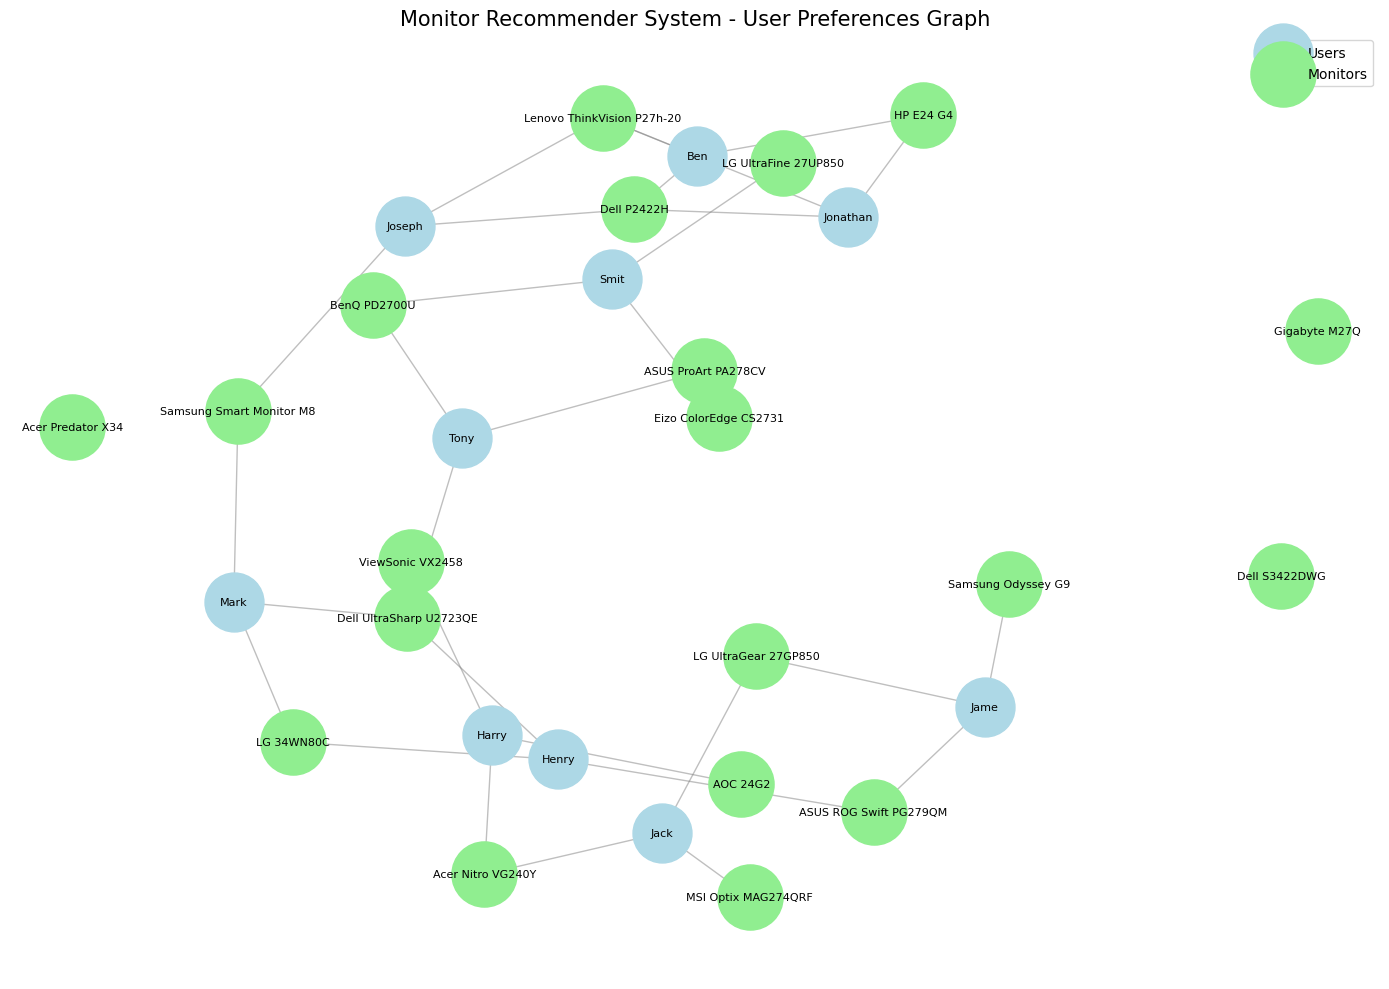

In [ ]:
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.6)

user_nodes = [n for n, attr in G.nodes(data=True) if attr.get('node_type') == 'user']
monitor_nodes = [n for n, attr in G.nodes(data=True) if attr.get('node_type') == 'monitor']

nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_color='lightblue', node_size=1800, label='Users')
nx.draw_networkx_nodes(G, pos, nodelist=monitor_nodes, node_color='lightgreen', node_size=2200, label='Monitors')
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Monitor Recommender System - User Preferences Graph", fontsize=15)
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
def recommend_monitors(G, target_user, top_n=5):
    recommendations = Counter()
    liked_monitors = set(G.neighbors(target_user))

    if not liked_monitors:
        return "ไม่พบข้อมูลความชอบ"

    for monitor in liked_monitors:
        for similar_user in G.neighbors(monitor):
            if similar_user == target_user:
                continue
            for other_monitor in G.neighbors(similar_user):
                if other_monitor not in liked_monitors:
                    recommendations[other_monitor] += 1

    return recommendations.most_common(top_n)

print("\n" + "="*13)
print("แนะนำจอคอมพิวเตอร์")
print("="*13)

for target in ["Tony"]:
    print(f"\n แนะนำจอคอมให้ '{target}':")
    print(f"   ชอบอยู่แล้ว: {list(G.neighbors(target))}")
    result = recommend_monitors(G, target)
    print(f"    แนะนำ:")
    for monitor, score in result:
        print(f"      - {monitor} (Score = {score})")


แนะนำจอคอมพิวเตอร์

 แนะนำจอคอมให้ 'Tony':
   ชอบอยู่แล้ว: ['Dell UltraSharp U2723QE', 'BenQ PD2700U', 'ASUS ProArt PA278CV']
    แนะนำ:
      - LG 34WN80C (Score = 2)
      - ASUS ROG Swift PG279QM (Score = 1)
      - Samsung Smart Monitor M8 (Score = 1)
      - Eizo ColorEdge CS2731 (Score = 1)
      - LG UltraFine 27UP850 (Score = 1)
